In [46]:
import sys

import pandas as pd

df=pd.read_csv("EURUSD_M15_2023_2025.csv")

df.head(20)

,time,open,high,low,close,tick_volume,spread,real_volume
0,2023-01-02 07:00:00,1.07016,1.07017,1.06909,1.06972,20,7,0
1,2023-01-02 07:15:00,1.06969,1.06979,1.06930,1.06938,15,7,0
2,2023-01-02 07:30:00,1.06929,1.06969,1.06929,1.06951,164,5,0
3,2023-01-02 07:45:00,1.06951,1.07001,1.06945,1.06967,141,1,0
4,2023-01-02 08:00:00,1.06971,1.06989,1.06936,1.06952,88,7,0
5,2023-01-02 08:15:00,1.06951,1.06960,1.06937,1.06941,166,7,0
6,2023-01-02 08:30:00,1.06939,1.06977,1.06938,1.06948,179,7,0
7,2023-01-02 08:45:00,1.06950,1.06955,1.06754,1.06935,121,5,0
8,2023-01-02 09:00:00,1.06916,1.06920,1.06812,1.06844,73,7,0
9,2023-01-02 09:15:00,1.06846,1.06868,1.06767,1.06810,86,7,0


In [47]:
df["real_volume"].unique()

array([0])

In [48]:
df = df.drop(columns=['real_volume'])

In [49]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49710 entries, 0 to 49709
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         49710 non-null  str    
 1   open         49710 non-null  float64
 2   high         49710 non-null  float64
 3   low          49710 non-null  float64
 4   close        49710 non-null  float64
 5   tick_volume  49710 non-null  int64  
 6   spread       49710 non-null  int64  
dtypes: float64(4), int64(2), str(1)
memory usage: 2.7 MB


In [50]:
df["time"] = pd.to_datetime(df["time"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49710 entries, 0 to 49709
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   time         49710 non-null  datetime64[us]
 1   open         49710 non-null  float64       
 2   high         49710 non-null  float64       
 3   low          49710 non-null  float64       
 4   close        49710 non-null  float64       
 5   tick_volume  49710 non-null  int64         
 6   spread       49710 non-null  int64         
dtypes: datetime64[us](1), float64(4), int64(2)
memory usage: 2.7 MB


In [51]:
df.isna().sum()

time           0
open           0
high           0
low            0
close          0
tick_volume    0
spread         0
dtype: int64

In [52]:
df.describe()

,time,open,high,low,close,tick_volume,spread
count,49710,49710.000000,49710.000000,49710.000000,49710.000000,49710.000000,49710.000000
mean,2023-12-31 16:55:13.452021,1.081844,1.082141,1.081544,1.081844,734.532348,1.781855
min,2023-01-02 07:00:00,1.033990,1.035030,1.033130,1.033980,5.000000,0.000000
25%,2023-06-30 19:48:45,1.071180,1.071480,1.070910,1.071182,268.000000,0.000000
50%,2024-01-02 07:37:30,1.083310,1.083600,1.083050,1.083320,477.000000,0.000000
75%,2024-07-01 21:41:15,1.092640,1.092900,1.092370,1.092640,857.750000,3.000000
max,2024-12-31 21:00:00,1.127190,1.127580,1.126450,1.127190,21483.000000,112.000000
std,NaN,0.016963,0.016946,0.016979,0.016964,865.190776,3.722404


In [53]:
df.iloc[:, 0].min(),df.iloc[:, 0].max()

(Timestamp('2023-01-02 07:00:00'), Timestamp('2024-12-31 21:00:00'))

In [54]:
df.iloc[:, 0].is_monotonic_increasing

True

In [55]:
df.shape

(49710, 7)

In [56]:
df.columns.to_list()

['time', 'open', 'high', 'low', 'close', 'tick_volume', 'spread']

In [57]:
(df["high"] < df["open"]).sum(),(df["high"] < df["close"]).sum()

(np.int64(0), np.int64(0))

In [58]:
(df["low"] > df["open"]).sum(),(df["low"] > df["close"]).sum()

(np.int64(0), np.int64(0))

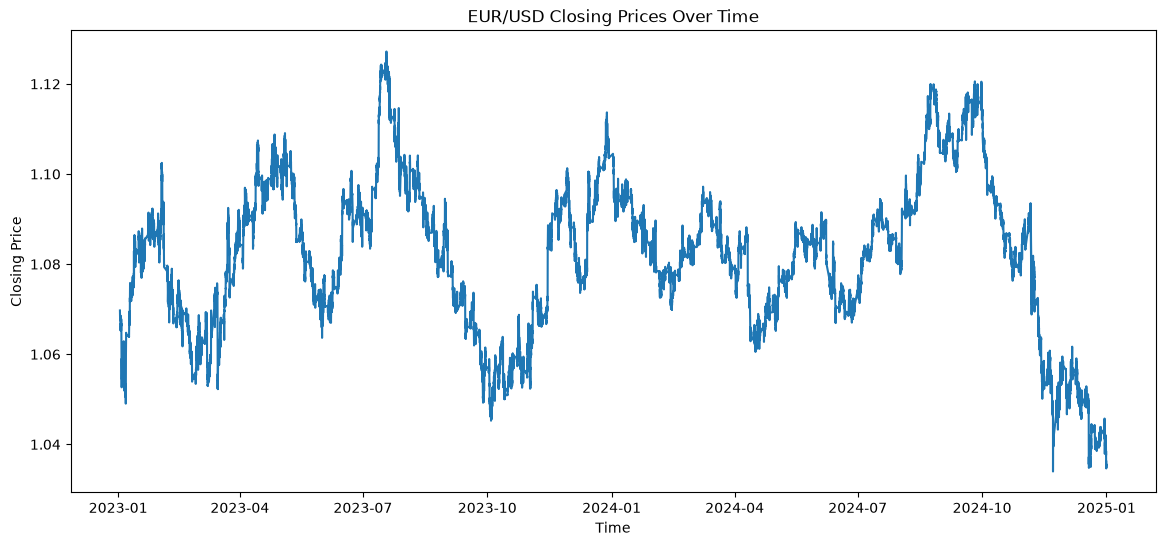

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
plt.plot(df["time"], df["close"])
plt.title("EUR/USD Closing Prices Over Time")
plt.xlabel("Time")
plt.ylabel("Closing Price")
plt.show()



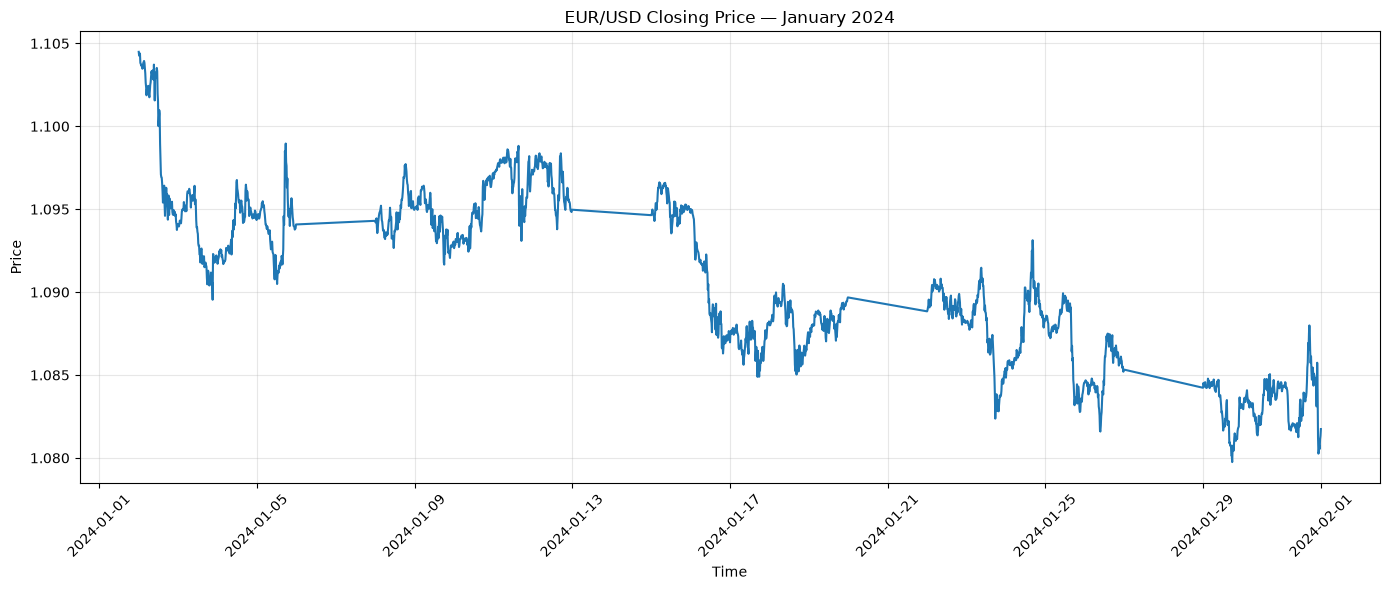

In [60]:
 

df_month = df[(df["time"] >= "2024-01-01") & 
              (df["time"] < "2024-02-01")]

plt.figure(figsize=(14, 6))

plt.plot(df_month["time"], df_month["close"])

plt.title("EUR/USD Closing Price — January 2024")
plt.xlabel("Time")
plt.ylabel("Price")

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [61]:
df["return"] = df["close"].pct_change()

In [62]:
df

,time,open,high,low,close,tick_volume,spread,return
0,2023-01-02 07:00:00,1.07016,1.07017,1.06909,1.06972,20,7,NaN
1,2023-01-02 07:15:00,1.06969,1.06979,1.06930,1.06938,15,7,-0.000318
2,2023-01-02 07:30:00,1.06929,1.06969,1.06929,1.06951,164,5,0.000122
3,2023-01-02 07:45:00,1.06951,1.07001,1.06945,1.06967,141,1,0.000150
4,2023-01-02 08:00:00,1.06971,1.06989,1.06936,1.06952,88,7,-0.000140
...,...,...,...,...,...,...,...,...
49705,2024-12-31 20:00:00,1.03489,1.03506,1.03455,1.03466,598,4,-0.000232
49706,2024-12-31 20:15:00,1.03464,1.03530,1.03460,1.03527,451,4,0.000590
49707,2024-12-31 20:30:00,1.03527,1.03566,1.03511,1.03565,415,4,0.000367
49708,2024-12-31 20:45:00,1.03563,1.03563,1.03526,1.03529,436,4,-0.000348


In [63]:
df["return"].describe()

count    4.970900e+04
mean    -5.436055e-07
std      4.409880e-04
min     -9.929621e-03
25%     -1.813444e-04
50%      0.000000e+00
75%      1.862822e-04
max      6.723488e-03
Name: return, dtype: float64

In [64]:
df.nlargest(30, "return")[["time", "close", "return"]]

,time,close,return
21710,2023-11-14 15:30:00,1.07957,0.006723
47173,2024-11-22 11:15:00,1.04085,0.006644
23748,2023-12-13 21:00:00,1.08502,0.005934
4772,2023-03-13 00:00:00,1.06981,0.005640
2170,2023-02-01 21:30:00,1.09728,0.005636
424,2023-01-06 17:00:00,1.05675,0.005586
803,2023-01-12 15:45:00,1.08291,0.005525
47224,2024-11-25 00:00:00,1.04717,0.005174
21038,2023-11-03 14:30:00,1.07084,0.005115
40960,2024-08-23 17:00:00,1.11652,0.004598


In [65]:
df.nsmallest(10, "return")[["time", "close", "return"]]

,time,close,return
47172,2024-11-22 11:00:00,1.03398,-0.009930
31689,2024-04-10 15:30:00,1.07808,-0.007466
2338,2023-02-03 15:30:00,1.08436,-0.007342
27766,2024-02-13 15:30:00,1.07173,-0.006968
48940,2024-12-18 21:00:00,1.04142,-0.006838
35721,2024-06-07 15:30:00,1.08327,-0.005718
43834,2024-10-04 15:30:00,1.09680,-0.005576
27094,2024-02-02 15:30:00,1.08277,-0.005173
4456,2023-03-07 17:00:00,1.05963,-0.004846
40378,2024-08-15 15:30:00,1.09609,-0.004559


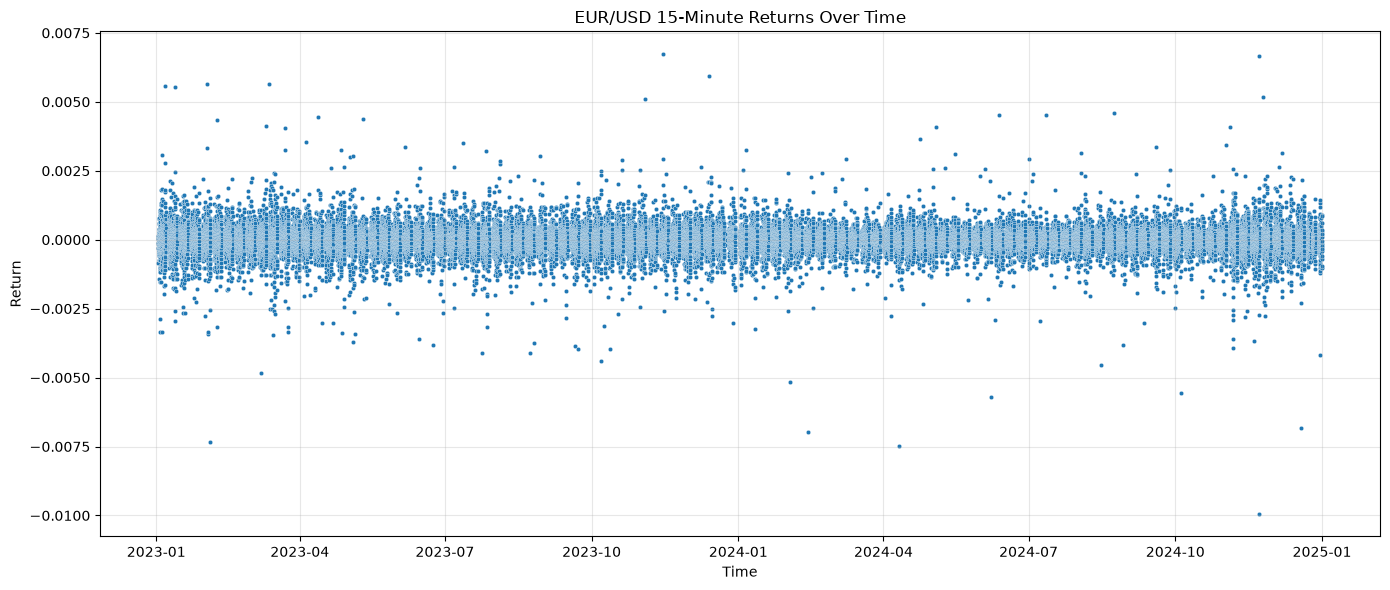

In [66]:
plt.figure(figsize=(14, 6))

sns.scatterplot(
    data=df,
    x="time",
    y="return",
    s=10
)

plt.title("EUR/USD 15-Minute Returns Over Time")
plt.xlabel("Time")
plt.ylabel("Return")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

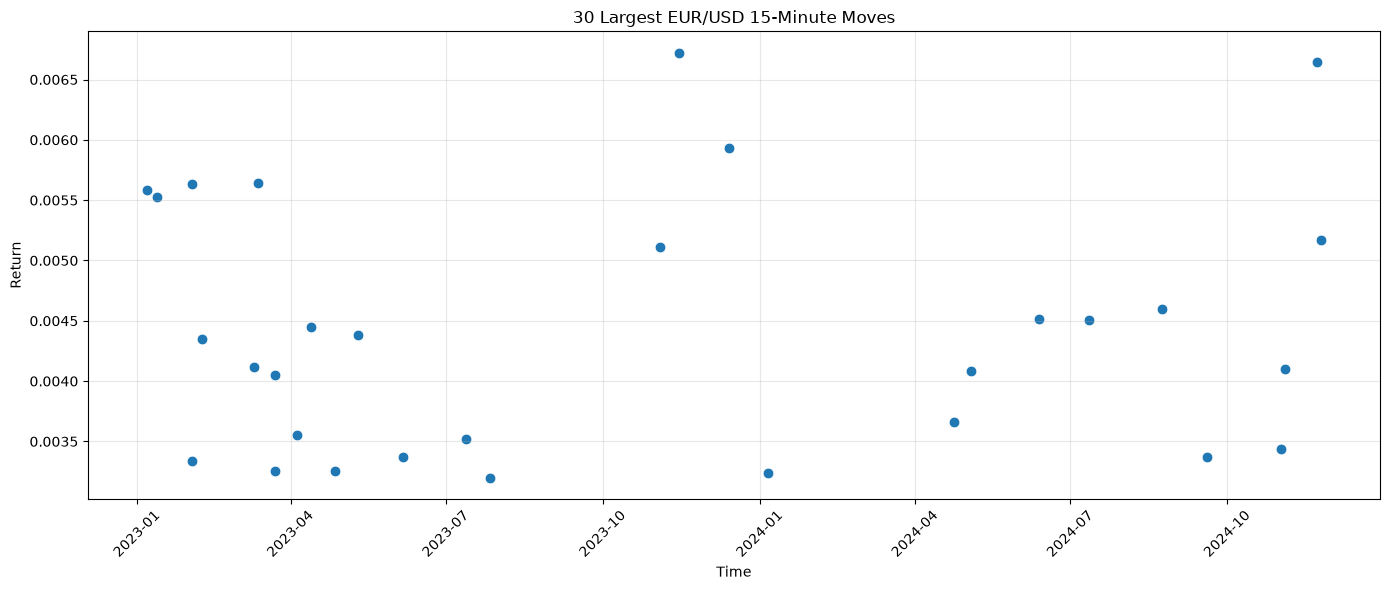

In [67]:
top_30 = df.nlargest(30, "return")[["time", "return"]]

top_30

plt.figure(figsize=(14, 6))

sns.scatterplot(
    data=top_30,
    x="time",
    y="return",
    s=60
)

plt.title("30 Largest EUR/USD 15-Minute Moves")
plt.xlabel("Time")
plt.ylabel("Return")

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()